# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Primero, el caso de users: esta columna tiene nulos significativos en la columna `city` que conforman el 11% de los datos de esa columna. Aunque no son tan grandes, son lo suficientemente grandes como para investigar si imputar o dejar como nulos. Por otro lado, la columna de `churn_date` tiene demasiados nulos, estos conformando el 88% del total de la misma. Acá decidiremos eliminar la columna directamente.

Segundo, el caso de usage. Acá tenemos 3 columnas con nulos, la primera es `date` cuyos nulos conforman menos del 1% total de la columna, siendo nada significativo, pudiendo dejarlas como nulos. Por otro lado, tanto la columna como `duration` y `lenght` sus nulos conforman casi la mitad de las columnas. Este caso es más delicado puesto que estas columnas conforman información esencial que necesitamos para las preguntas del negocio. Vamos a decidir analizar para ver si esos nulos tienen alguna relación externa o interna, para saber si es error de registro o algo mas. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [13]:
# cuántas veces aparece el sentinela
print((users['age'] == -999).sum())

# proporción del sentinela
print((users['age'] == -999).value_counts(normalize=True))

55
False    0.98625
True     0.01375
Name: age, dtype: float64


- La columna `user_id` no muestra sentinels significativos. 
- La columna `age` muestra un sentinel representado por "-999", probablemente siendo esta la razón por la cual el promedio sea tan bajo comparado a la edad máxima.

In [14]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no demuestran sentinels.
- Las columnas `duration` y `lenght` tampoco demuestran sentinels. Sin embargo, sí hay nulos como lo habíamos dicho en pasos anteriores. 

In [15]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]

print(columnas_user.describe())
print() #verificamos las combinaciones en busca de sentinels
print(columnas_user.value_counts())
print() #comprobamos el sentinel en la columna 'city'
print(users['city'].unique())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [16]:
#proporción del sentinela
print((users['city'] == "?").value_counts(normalize=True))

False    0.976
True     0.024
Name: city, dtype: float64


- La columna `city` refleja lo que habíamos expuesto anteriormente con respecto a los nulos, faltando varios. Son 7 ciudades únicas registradas con Bogotá como la top de todas. Sin embargo, haciendo doble validación, hallamos un sentinel con el valor "?" en la columna `city`
- La columna `plan` que el plan básico es el más adquirido por los usuarios, aún así, no supera el 50% por mucho, por lo que los usuarios de plan premium también son significativos.

In [17]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` demuestra que en cuanto a frecuencia, los usuarios usan mas los mensaje de texto comparado a las llamadas. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

En general, sin contar los NaN, los dataset están libres de sentinelas exceptuando la columna `age` y `city` del dataset 'users' donde hay un sentinela de "-999" y "?" respectivamente. Al ver que corresponden a solo el 1% y 2% de los datos respectivamente, tomaría la acción de revisar si están relacionados con algo más y reemplazar como nulos o la mediana al ser pocos casos. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [20]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

# Revisión de la frecuencia de los años
print(users['reg_date'].dt.year.value_counts())

# Revisión de la proporción de cada año
print(users['reg_date'].dt.year.value_counts(normalize=True))

[2022 2026 2023 2024]
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64
2024    0.3325
2023    0.3290
2022    0.3285
2026    0.0100
Name: reg_date, dtype: float64


En `reg_date`, encontramos años imposibles, el cual es 2026, apareciendo un total de 40 veces y conformando el 1% de la columna. Recordemos que la información registrada es hasta el año 2024

In [21]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

# Revisión de los nulos
print(usage['date'].isna().sum())

# Proporción de nulos con respecto a la columna
print(usage['date'].isna().mean())

[2024.   nan]
50
0.00125


En `date` no hay años sentinelas ni imposibles, sin embargo, al hacer la conversión a tipo fecha, sí se encontró 50 nulos. Sin embargo, estos conforman menos del 1% de los datos totales.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Solo hay un caso de fechas imposibles y es 2026 en "users". No obstante, al ser tan solo el 1%, podemos imputarlas como nulos para así no perder los demás datos de los usuarios. Por otro lado, en el dataset "usage", al hacer la conversión a fechas se encontraron 50 nulos, que son menos del 1% de los datos (0,01%). En este caso, lo mejor es revisar la razón del por qué, ya que estos nulos acompañan a un dataset que, en general, tiene demasiados nulos en total como vimos anteriormente. Se recomienda, en ambos casos, revisar la razón para así verificar si los dejamos como nulos o si los imputamos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print(users['city'].unique())

['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.unique())

[2022.   nan 2023. 2024.]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

`duration`: Acá los nulos sin duda tienen una relación con text, que es donde están practicamente todos los nulos. El diagnóstico que le doy es de MNAR, puesto que la razón es por el mismo valor en sí. Los mensajes de texto al ser carácteres escrito, no tiene sentido su medición en duración ya que las personas pueden mandar mensajes en distintos momentos, en cambio, su medición es en cuanto a longitud, medido en los mensajes o cantidad de carácteres que se envíanm, es decir, los mensajes se miden en `length`. 

`length`: Acá pasa lo mismo que el caso anterior solo que viceversa, todos los nulos corresponden al tipo llamadas. El diagnóstico que le doy es de MNAR, siguiendo la misma lógica, no tiene sentido medir las llamadas en cuanto a longitud ya que no hay nada que medir en ese sentido, en cambio, las llamadas sí se miden por el tiempo de duración que estuvo abierta y luego fue cerrada. Por tanto, la naturaleza del nulo recae en el mismo valor, tiene sentido con los datos analizados y por eso califica como MNAR. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id', dropna=False).agg({'is_text':'sum', 'is_call':'sum', 'duration':'sum'}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call':'cant_llamadas', 'duration':'cant_minutos_llamada'})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# ¿Cuántos user_id de usage_agg NO están en users?
(~usage_agg['user_id'].isin(users['user_id'])).sum()

0

In [30]:
# ¿Cuántos user_id de users NO están en usage_agg?
(~users['user_id'].isin(usage_agg['user_id'])).sum()

1

In [31]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [33]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

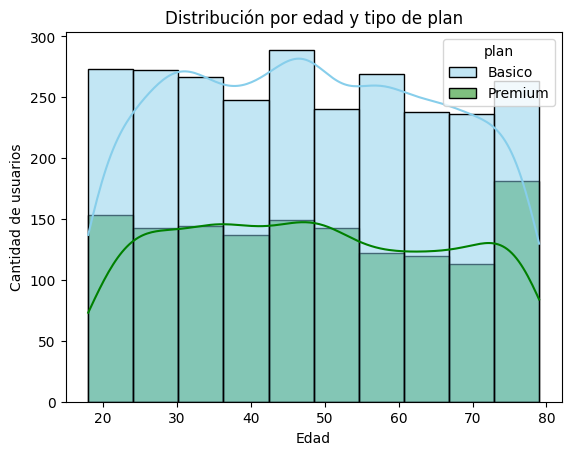

In [34]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=10, kde=True)
plt.title("Distribución por edad y tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- En general, hay una proporción de usuarios similar en el plan premium para todas las edades, excepto a partir de los 50 años donde hay una bajada, no tan pronunciada, pero sí lo suficientemente considerable. Con respecto a l plan básico, aquí ya hay distintos picos, podemos reconocer dos montañas, mostrando que estamos ante frecuencia bimodal. No obstante, estos picos se concentran en edades relativamente jóvenes, entre 30 años y 50, punto en donde hay una bajada considerable. Podríamos decir que em ambos casos, hay una distribución considerablemente simétrica. 

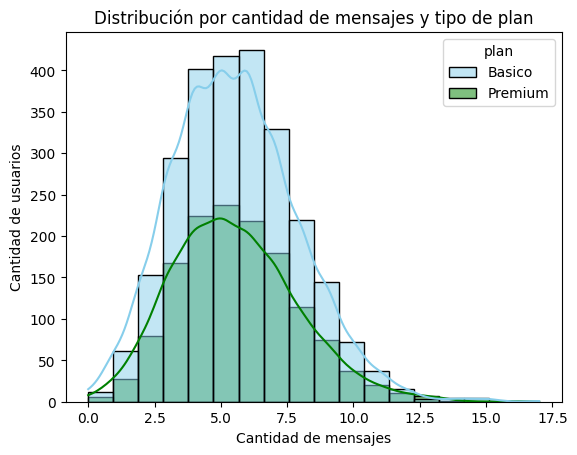

In [35]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=18, kde=True)
plt.title("Distribución por cantidad de mensajes y tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Tenemos una distribución ligeramente sesgada a la derecha, con pocos casos de usuarios con cantidad de mensajes mayores a 10 pero lo suficiente como para arrastrar la cola. Por otro lado, notamos una colina única y marcada en el plan premium, viendo que muchos usuarios de este plan envían entre 5 a 7 mensajes. El plan básico también sigue esta misma tendencia, con pequeñas diferencias marcadas, sin embargo, en general siguen la misma montaña al rededor de los mismos datos. En resumen, vemos una distribución ligeramente sesgada a la derecha con una moda marcada, no hay mayor diferencia entre el plan básico y premium en cuanto a cantidad de mensajes. 

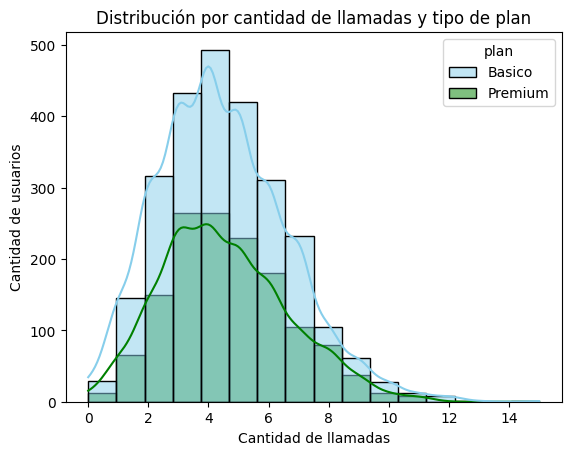

In [36]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=16, kde=True)
plt.title("Distribución por cantidad de llamadas y tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Distribución sesgada a la derecha, en ambos planes. Vemos que ambos grupos siguen la misma tendencia, con la mayor parte de usuarios haciendo de 4 a 5 llamadas. Hay casos altos con usuarios con cantidad de llamadas mayor a 10, pero son escasos, sin embargo, lo suficientemente significativos como para arrastrar la cola. La montaña varía un poco en el plan básico, sin embargo, el pico es al rededor de la misma frecuencia que los usuarios del plan premium.

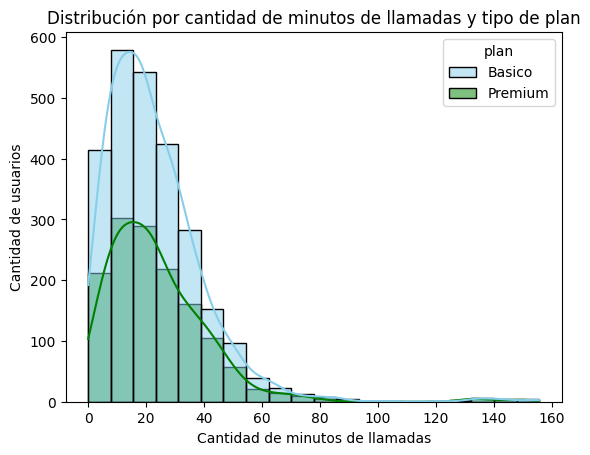

In [37]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=20, kde=True)
plt.title("Distribución por cantidad de minutos de llamadas y tipo de plan")
plt.xlabel("Cantidad de minutos de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Nuevamente estamos ante un caso de distribución con sesgo a la derecha, sin embargo, este caso sí es considerablemente más marcado que los demás. Hay suficiente llamadas con minutos lo suficientemente grandes como para elevar la cola e, incluso, halla una ligera elevación. Sin embargo, así como los demás, la moda se concentra en los datos pequeños: la mayoría de usuarios hicieron llamadas con duración de 20 minutos. Este comportamiento es igual tanto en usuarios de plan básico como plan premium, nuevamente compartiendo comportamiento ambos grupos como bien hemos visto en todos los histogramas hasta ahora.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

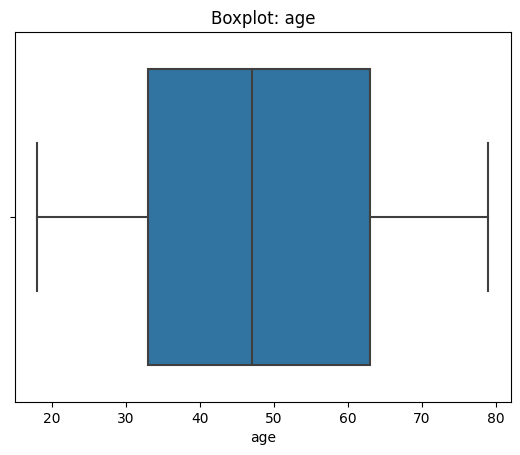

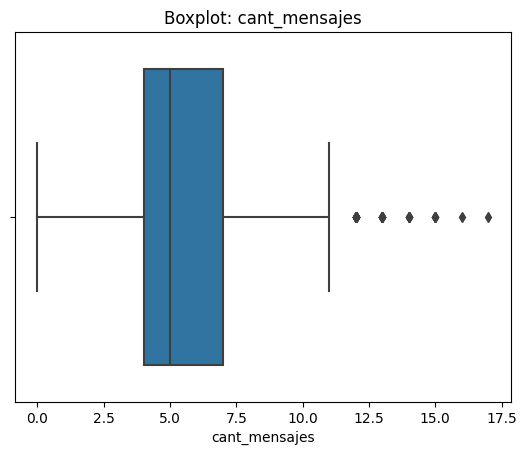

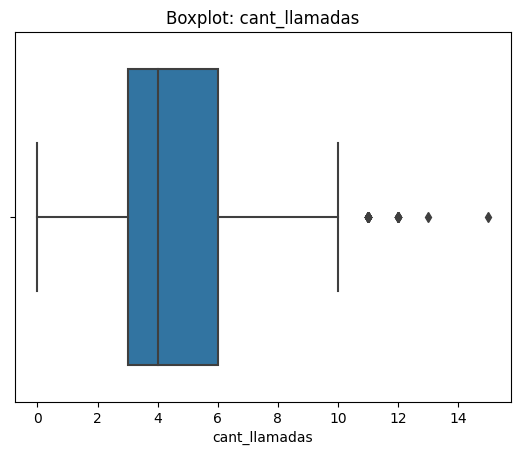

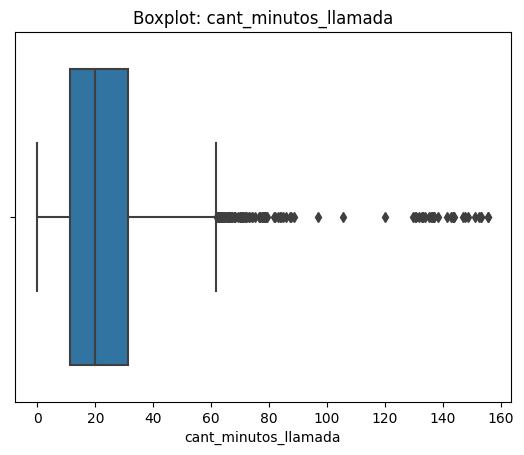

In [38]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: Como pudimos deducir en base al histograma, sí hay outliers. Sin embargo, a pesar de ser varios, no son tantos ni tan significativos. 
- cant_llamadas: Aquí también pudimos haberlo deducido gracias al histograma y es que también hay outliers. Mucho menos que con la cantidad de mensajes, por tanto su efecto tampoco es tan drástico. 
- cant_minutos_llamada: Aquí sí hay muchos outliers, como vimos en el histograma con una cola a la derecha muy estirada, hay bastantes casos cuyas llamadas superaron los 60 minutos y se salen de la caja. 

In [39]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    IQR = (user_profile[col].quantile(0.75)) - (user_profile[col].quantile(0.25))
    print(f'Límite superior {col}')
    limite_superior = (user_profile[col].quantile(0.75)) + 1.5 * IQR
    print(limite_superior)

Límite superior age
108.0
Límite superior cant_mensajes
11.5
Límite superior cant_llamadas
10.5
Límite superior cant_minutos_llamada
61.8575


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Decidimos mantener el outlier. Apesar de que no son tantos los casos y por ende podríamos winsorizarlos, lo mantenemos porque tampoco está tan alejado del límite superior, hablamos de que el máximo a penas tiene una diferencia de 5 puntos con respecto a su límite, no simboliza gran sesgo a la hora de analizar los datos y a su vez representa un dato real.
- cant_llamadas: También decidimos mantener el outlier. Se repite un caso similar al anterior, los outliers no tienen tanta distancia con su límite superior, por tanto, no son un sesgo tan marcado a la hora de analizar los datos, a su vez que representan un comportamiento real del usuario. 
- cant_minutos_llamada: Acá decidimos que lo mejor es mantenerlos. A pesar de que son outliers grandes y alejados del límite superior (el cual es 61,85), no son errores ya que entran dentro de lo esperable y en datos reales. Una llamada de 155 minutos no es tan rara. Si decidimos caparlos, incrementaríamos artificalmente las llamadas con duración de 60 minutos, sesgando aún más nuestra muestra, lo que sería contraproducente. Por esta razón, keep es la decisión que tomaremos. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso
def classify_segment(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Usuario sin información"

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso'] = user_profile.apply(classify_segment, axis=1)

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
def classify_age(row):
    edad = row['age']

    if pd.isna(edad):
        return "Usuario sin información"

    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile['grupo_edad'] = user_profile.apply(classify_age, axis=1)

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

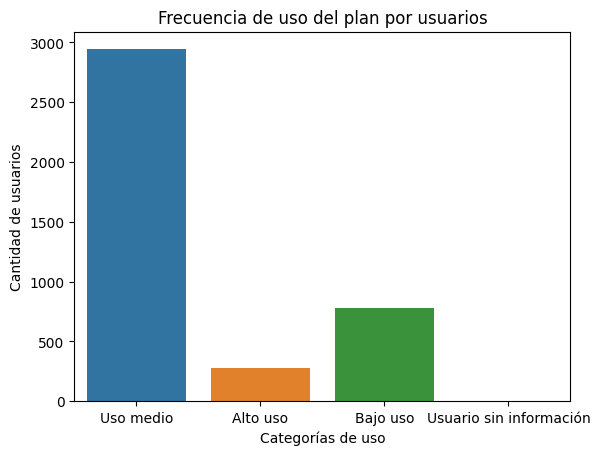

In [47]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title("Frecuencia de uso del plan por usuarios")
plt.xlabel("Categorías de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

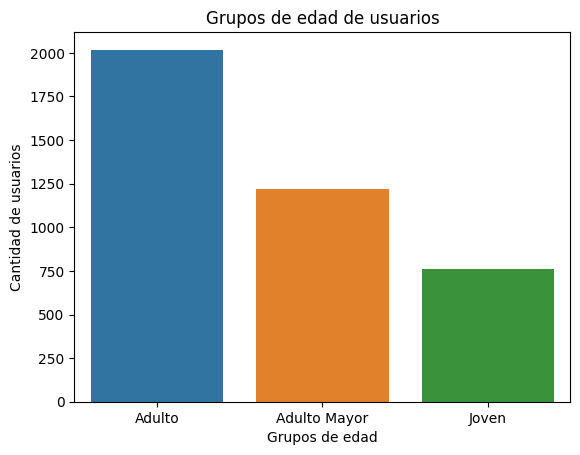

In [48]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title("Grupos de edad de usuarios")
plt.xlabel("Grupos de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Primero, el caso de users: esta columna tiene nulos significativos en la columna city que conforman el 11% de los datos de esa columna. Aunque no son tan grandes, son lo suficientemente grandes como para investigar si imputar o dejar como nulos. Por otro lado, la columna de churn_date tiene demasiados nulos, estos conformando el 88% del total de la misma. Acá decidimos revisar si había una razón del por qué, encontrando que era normal por la naturaliza de los datos.
- Segundo, el caso de usage. Acá tenemos 3 columnas con nulos, la primera es date cuyos nulos conforman menos del 1% total de la columna, siendo nada significativo, pudiendo dejarlas como nulos. Por otro lado, tanto la columna como duration y lenght sus nulos conforman casi la mitad de las columnas. Este caso es más delicado puesto que estas columnas conforman información esencial que necesitamos para las preguntas del negocio. Vamos a decidir analizar para ver si esos nulos tienen alguna relación externa o interna, para saber si es error de registro o algo mas.
- Las columnas `id` y `user_id` no demuestran sentinels.
- Las columnas `duration` y `lenght` tampoco demuestran sentinels. Sin embargo, sí hay nulos como lo habíamos dicho en pasos anteriores.
- La columna `city` refleja lo que habíamos expuesto anteriormente con respecto a los nulos, faltando varios. Son 7 ciudades únicas registradas con Bogotá como la top de todas. Sin embargo, haciendo doble validación, hallamos un sentinel con el valor "?" en la columna `city`
- La columna `plan` que el plan básico es el más adquirido por los usuarios, aún así, no supera el 50% por mucho, por lo que los usuarios de plan premium también son significativos.
- La columna `type` demuestra que en cuanto a frecuencia, los usuarios usan mas los mensaje de texto comparado a las llamadas.
- En general, sin contar los NaN, los dataset están libres de sentinelas exceptuando la columna `age` y `city` del dataset 'users' donde hay un sentinela de "-999" y "?" respectivamente. Al ver que corresponden a solo el 1% y 2% de los datos respectivamente, tomaría la acción de revisar si están relacionados con algo más y reemplazar como nulos o la mediana al ser pocos casos.
- Solo hay un caso de fechas imposibles y es 2026 en "users". No obstante, al ser tan solo el 1%, podemos imputarlas como nulos para así no perder los demás datos de los usuarios. Por otro lado, en el dataset "usage", al hacer la conversión a fechas se encontraron 50 nulos, que son menos del 1% de los datos (0,01%). En este caso, lo mejor es revisar la razón del por qué, ya que estos nulos acompañan a un dataset que, en general, tiene demasiados nulos en total como vimos anteriormente. Se recomienda, en ambos casos, revisar la razón para así verificar si los dejamos como nulos o si los imputamos.


🔍 **Segmentos por Edad**
- Vemos que generalmente el grupo de adultos (entre 30 y 60 años) es el que más concentración de usuarios tiene. Le siguen los adultos mayores (superior a 30 años) mostrando que, en general, la gente mayor de 30 suele ser el público que mayormente consume los planes de ConnectaTel. 
- Por otro lado, el público minoritario es sin duda el joven, conformado por aquellos menores a los 30 años. No obstante, no son tan menores comparados a los otros dos grupos, mostrando que aunque se quedan atrás, siguien siendo un público objetivo importante para la compañía.
- No hubo outliers en este apartado. 


📊 **Segmentos por Nivel de Uso**
- El uso medio es el que mayor predomina de los 3 grupos. A diferencia de los segmentos por edad, aquí el grupo predominante sí se aleja con una mayor diferencia de usuarios comparado al resto, demostrando que los clientes no suelen abandonar el plan, pero tampoco lo usan en exceso. Están en un rango medio. 
- Por otro lado, los usuarios de uso bajo son bastante escasos y los de uso alto, a pesar de ser menores en cuanto a frecuencia, los que son parte de ellos tienden a usar mucho el plan, tanto que hay outliers considerables en este apartado.


➡️ Esto sugiere que el público objetivo mayoritario son los Adultos mayores a 30 años que usan los planes en un rango medio, pero con usuarios que pertenecen al grupo que usan el plan en un rango alto, que llegan a utilizarlo más allá de lo normal, siendo outliers considerables. 


💡 **Recomendaciones**
- Crear nuevos planes para el segmento que usa el plan poco y para los que lo usan mucho, con precios reducidos o aumentados respectivamente con beneficios que le pudieran interesar a ambos grupos. Por ejemplo, las personas que no usan casi el plan podrían verse interesados por opciones más económicas, con limitaciones pero que se ajusta a su necesidad, eso a su vez podría traer nuevos clientes que no adquieren un plan porque piensan no lo usarán todo y por eso no valdrá la pena. Por el lado de los clientes de consumo alto, podríamos aprovechar a los outliers con planes dedicados, ya que usan el servicio de forma extraordinariamente alta, podríamos darles beneficios de fidelidad o incluso crear un plan en específico para ellos con más funciones que podrían aprovechar. 
- Por el lado de las edades, podríamos impulsar el uso del servicio en las personas jóvenes con marketing y beneficios focalizados a las personas de esa edad, investigar por qué no están eligiendo nuestros productos y aumentar el consumo. Por el lado de los adultos, aunque por ahora tenemos un público sólido, se podría recomendar aumentar su fidelidad mediante campañas o beneficios a largo plazo que las personas de ese rango de edad podrían interesarle. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`